# Notebook 2 — Curse of Dimensionality: Why Prior Sampling Fails

## Core idea

The **mode** of $\mathcal{N}(0, I_D)$ is the origin — the point with the highest probability *density*.

Yet if you draw a sample $z \sim \mathcal{N}(0, I_D)$, it will **never** land near the origin once $D$ is large.
All the probability *mass* concentrates on a thin spherical shell at radius $\approx \sqrt{D}$, far from the mode:

$$\|z\| \approx \sqrt{D} \qquad (\text{typical sample radius})$$

This is the **density–mass divorce**: density lives at the origin; mass lives on the shell.

### Key fact used throughout

If $z \sim \mathcal{N}(0, I_D)$ then $\|z\|^2 \sim \chi^2_D$, so the radius
$\|z\| \sim \chi_D$ (a chi distribution with $D$ degrees of freedom).
The radial density (probability density of the scalar $r = \|z\|$) is

$$p_\text{radial}(r) \propto r^{D-1}\, e^{-r^2/2}$$

which peaks at $r^* = \sqrt{D-1}$, while the *point* density $p(z) \propto e^{-\|z\|^2/2}$
peaks at the origin for every $D$.

### Why does this matter for generative models?

In Notebook 1 we estimated $\log p_\theta(x_i)$ by sampling $z^{(m)} \sim p(z)$ and
evaluating $p_\theta(x_i \mid z^{(m)})$.
Each $x_i$ has a small **posterior pocket** — the region of $z$-space that actually
explains it. In high dimensions, prior samples almost never land there, so the
estimator's effective sample size collapses and gradients become noise.

This notebook builds that intuition step by step.

In [1]:
import os
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from mpl_toolkits.mplot3d import Axes3D   # noqa: F401 – registers 3D projection

# ── reproducibility ───────────────────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)

# ── figures folder ────────────────────────────────────────────────────────────
os.makedirs("figures", exist_ok=True)

plt.rcParams.update({"figure.dpi": 120, "font.size": 11})
print("Setup complete.  NumPy", np.__version__, " | SciPy", stats.chi2.name)

Setup complete.  NumPy 1.26.4  | SciPy chi2


## Figure 1 — Where do samples actually live in 1D, 2D, and 3D?

In 1D roughly 68% of samples fall within 1σ of the mean.
In 2D that fraction is already down to 39%, in 3D only 20%.

The exact fractions are $P(\|z\|^2 \le 1) = \chi^2_D\!\operatorname{.cdf}(1)$
— and they keep falling as $D$ grows.

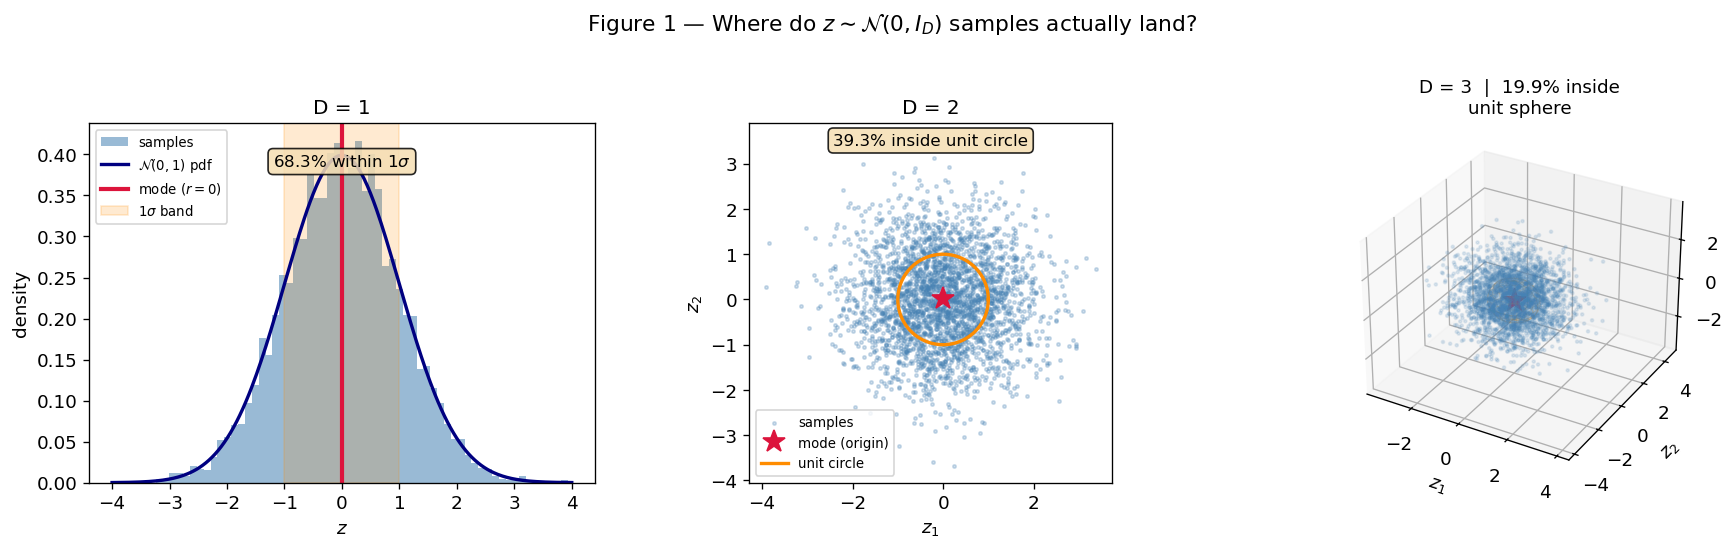


Fraction of mass inside the 1σ unit ball:
  D= 1: 68.269%
  D= 2: 39.347%
  D= 3: 19.875%
  D= 5: 3.743%
  D=10: 0.017%


In [2]:
np.random.seed(SEED)

C_SCATTER = "steelblue"
C_MODE    = "crimson"
C_BAND    = "darkorange"

fig = plt.figure(figsize=(15, 4.5))
gs  = gridspec.GridSpec(1, 3, figure=fig)

# ── 1-D ───────────────────────────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0])
z1  = np.random.randn(5000)
ax1.hist(z1, bins=60, density=True, color=C_SCATTER, alpha=0.55, label="samples")
_x  = np.linspace(-4, 4, 300)
ax1.plot(_x, stats.norm.pdf(_x), "navy", lw=2, label=r"$\mathcal{N}(0,1)$ pdf")
ax1.axvline(0, color=C_MODE, lw=2.5, label="mode ($r=0$)")
ax1.axvspan(-1, 1, alpha=0.18, color=C_BAND, label=r"$1\sigma$ band")
f1 = stats.chi2.cdf(1, df=1)
ax1.text(0.5, 0.88, f"{100*f1:.1f}% within $1\\sigma$",
         transform=ax1.transAxes, ha="center", fontsize=10,
         bbox=dict(boxstyle="round,pad=0.3", fc="wheat", alpha=0.85))
ax1.set_title("D = 1", fontsize=12)
ax1.set_xlabel("$z$"); ax1.set_ylabel("density")
ax1.legend(fontsize=8, loc="upper left")

# ── 2-D ───────────────────────────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[1])
z2  = np.random.randn(3000, 2)
ax2.scatter(z2[:, 0], z2[:, 1], s=4, alpha=0.25, color=C_SCATTER, label="samples")
ax2.plot(0, 0, "*", color=C_MODE, ms=14, label="mode (origin)", zorder=5)
_th = np.linspace(0, 2 * np.pi, 300)
ax2.plot(np.cos(_th), np.sin(_th), color=C_BAND, lw=2, label="unit circle")
f2 = stats.chi2.cdf(1, df=2)
ax2.text(0.5, 0.94, f"{100*f2:.1f}% inside unit circle",
         transform=ax2.transAxes, ha="center", fontsize=10,
         bbox=dict(boxstyle="round,pad=0.3", fc="wheat", alpha=0.85))
ax2.set_title("D = 2", fontsize=12)
ax2.set_xlabel("$z_1$"); ax2.set_ylabel("$z_2$")
ax2.set_aspect("equal"); ax2.legend(fontsize=8)

# ── 3-D ───────────────────────────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[2], projection="3d")
z3  = np.random.randn(3000, 3)
ax3.scatter(z3[:, 0], z3[:, 1], z3[:, 2],
            s=3, alpha=0.15, color=C_SCATTER, depthshade=True)
ax3.scatter([0], [0], [0], s=200, color=C_MODE, marker="*", zorder=10)
# wireframe unit sphere
_u  = np.linspace(0, 2 * np.pi, 20)
_v  = np.linspace(0, np.pi, 12)
_xs = np.outer(np.cos(_u), np.sin(_v))
_ys = np.outer(np.sin(_u), np.sin(_v))
_zs = np.outer(np.ones_like(_u), np.cos(_v))
ax3.plot_wireframe(_xs, _ys, _zs, alpha=0.25, color=C_BAND, linewidth=0.5)
f3 = stats.chi2.cdf(1, df=3)
ax3.set_title(f"D = 3  |  {100*f3:.1f}% inside\nunit sphere", fontsize=11)
ax3.set_xlabel("$z_1$"); ax3.set_ylabel("$z_2$"); ax3.set_zlabel("$z_3$")

plt.suptitle(
    r"Figure 1 — Where do $z \sim \mathcal{N}(0,I_D)$ samples actually land?",
    fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("figures/fig1_low_dim.png", dpi=200, bbox_inches="tight")
plt.show()

print("\nFraction of mass inside the 1σ unit ball:")
for D in [1, 2, 3, 5, 10]:
    print(f"  D={D:2d}: {100*stats.chi2.cdf(1, df=D):.3f}%")

## Figure 2 — Density says "centre", mass says "shell"

The Gaussian **point density** $p(z) = (2\pi)^{-D/2} e^{-\|z\|^2/2}$ is maximum at $z = 0$ for every $D$.

The **radial density** of the radius $r = \|z\|$ is

$$p_\text{radial}(r) \;\propto\; \underbrace{r^{D-1}}_{\text{sphere surface }\propto r^{D-1}} \cdot \underbrace{e^{-r^2/2}}_{\text{Gaussian point density}}$$

The surface-area factor $r^{D-1}$ grows so fast that it overwhelms the Gaussian and pulls the peak away from the origin.

| $D$ | mode of $p(z)$ | peak of $p_\text{radial}(r)$ |
|-----|----------------|------------------------------|
| 1   | $r = 0$ | $r = 0$ |
| 2   | $r = 0$ | $r = \sqrt{1} = 1$ |
| 10  | $r = 0$ | $r = \sqrt{9} = 3$ |
| 50  | $r = 0$ | $r = \sqrt{49} = 7$ |

As $D$ grows the two concepts — "highest density" and "where a sample lands" — diverge completely.

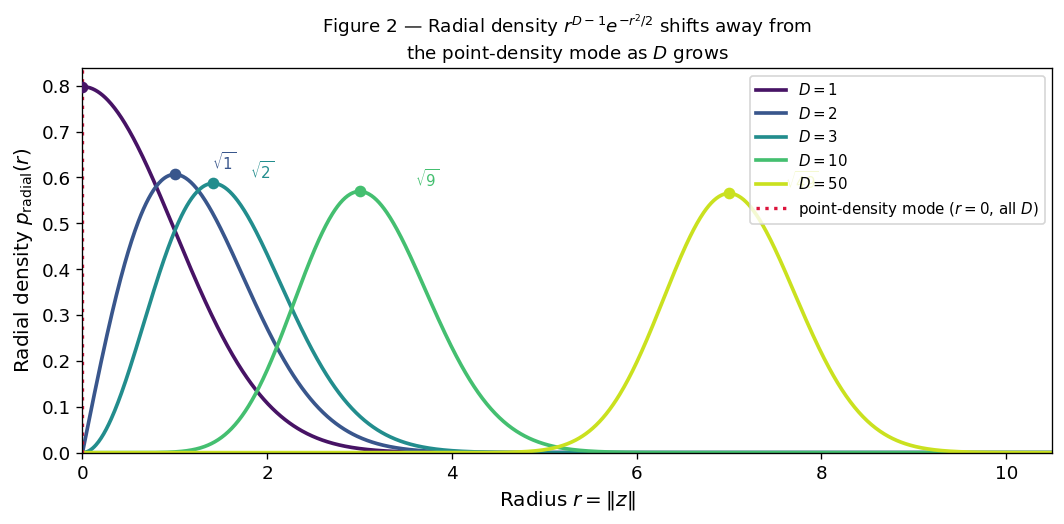

In [3]:
DIMS_2  = [1, 2, 3, 10, 50]
COLORS2 = plt.cm.viridis(np.linspace(0.05, 0.92, len(DIMS_2)))

r = np.linspace(1e-4, 11, 1200)

fig, ax = plt.subplots(figsize=(9, 4.5))

for D, col in zip(DIMS_2, COLORS2):
    pdf_r = stats.chi.pdf(r, df=D)
    ax.plot(r, pdf_r, color=col, lw=2.2, label=f"$D = {D}$")
    # mark the mode of the radial density
    peak_r = np.sqrt(max(D - 1, 0))
    peak_v = stats.chi.pdf(peak_r + 1e-6, df=D)
    ax.plot(peak_r, peak_v, "o", color=col, ms=6, zorder=5)
    if D >= 2:
        label_x = peak_r + (0.4 if D < 10 else 0.6)
        ax.annotate(
            f"$\\sqrt{{{D-1}}}$",
            xy=(peak_r, peak_v),
            xytext=(label_x, peak_v + 0.01),
            fontsize=9, color=col,
        )

# the mode of the POINT density is always r = 0
ax.axvline(0, color="crimson", lw=2, linestyle=":",
           label="point-density mode ($r=0$, all $D$)")

ax.set_xlabel(r"Radius $r = \|z\|$", fontsize=12)
ax.set_ylabel(r"Radial density $p_\mathrm{radial}(r)$", fontsize=12)
ax.set_title(
    r"Figure 2 — Radial density $r^{D-1}e^{-r^2/2}$ shifts away from"
    "\nthe point-density mode as $D$ grows",
    fontsize=11,
)
ax.set_xlim(0, 10.5); ax.set_ylim(bottom=0)
ax.legend(fontsize=9, loc="upper right")
plt.tight_layout()
plt.savefig("figures/fig2_radial_density.png", dpi=200)
plt.show()

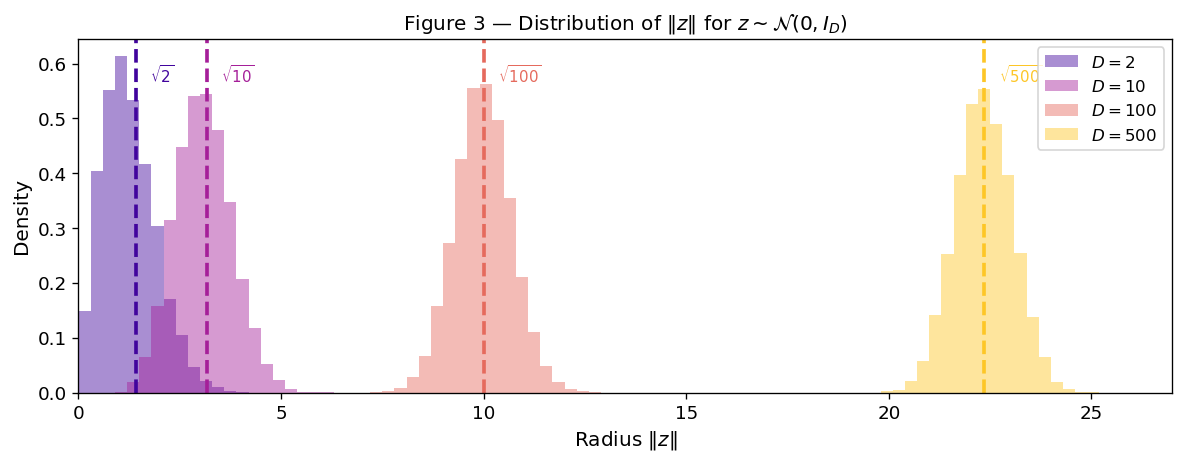

In [4]:
# ── Figure 3: histogram of ||z|| — the thin-shell effect ────────────────────
np.random.seed(SEED)

DIMS_3  = [2, 10, 100, 500]
N_SAMP  = 15_000
COLORS3 = plt.cm.plasma(np.linspace(0.10, 0.88, len(DIMS_3)))

fig, ax = plt.subplots(figsize=(10, 4))

for D, col in zip(DIMS_3, COLORS3):
    z      = np.random.randn(N_SAMP, D)
    radii  = np.linalg.norm(z, axis=1)
    ax.hist(radii, bins=90, density=True, alpha=0.45, color=col,
            label=f"$D = {D}$", range=(0, 27))

# annotate expected radius sqrt(D) — add vertical lines AFTER all histograms
for D, col in zip(DIMS_3, COLORS3):
    ax.axvline(np.sqrt(D), color=col, lw=2.2, linestyle="--")
    ax.annotate(
        f"$\\sqrt{{{D}}}$",
        xy=(np.sqrt(D), 1.0),
        xycoords=("data", "axes fraction"),
        xytext=(np.sqrt(D) + 0.35, 0.93),
        textcoords=("data", "axes fraction"),
        fontsize=9, color=col, va="top",
    )

ax.set_xlabel(r"Radius $\|z\|$", fontsize=12)
ax.set_ylabel("Density", fontsize=12)
ax.set_title(
    r"Figure 3 — Distribution of $\|z\|$ for $z \sim \mathcal{N}(0, I_D)$",
    fontsize=12,
)
ax.set_xlim(0, 27)
ax.legend(fontsize=10, loc="upper right")
plt.tight_layout()
plt.savefig("figures/fig3_thin_shell.png", dpi=200)
plt.show()

The onion collapses to one layer: as $D$ grows the shell shrinks (relative width $\sim 1/\sqrt{D}$) and concentrates tightly around $\sqrt{D}$.

## Figure 4 — How much mass is near the mode as dimension grows?

The fraction of the prior's mass that falls inside the unit ball (the "mode's neighbourhood") is

$$P\!\left(\|z\| \le 1\right) = P\!\left(\chi^2_D \le 1\right) = \chi^2_D\!\operatorname{.cdf}(1)$$

Starting at 68% for $D = 1$, this falls exponentially toward zero.

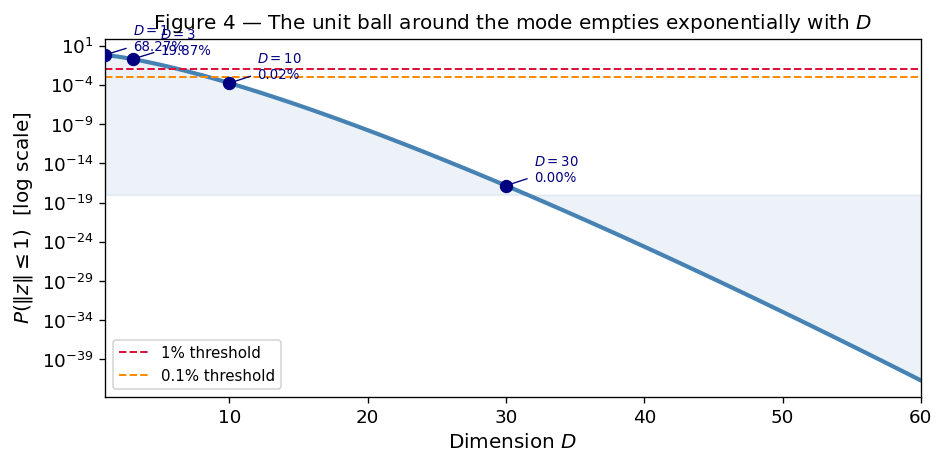

P(||z|| ≤ 1) at selected D:
  D=  1: 68.26895%
  D=  2: 39.34693%
  D=  3: 19.87480%
  D=  5: 3.74342%
  D= 10: 0.01721%
  D= 20: 0.00000%
  D= 40: 0.00000%
  D= 60: 0.00000%


In [5]:
D_range  = np.arange(1, 61)
p_inside = stats.chi2.cdf(1.0, df=D_range)

fig, ax = plt.subplots(figsize=(8, 4))
ax.semilogy(D_range, p_inside, color="steelblue", lw=2.5)
ax.fill_between(D_range, p_inside, 1e-18, alpha=0.10, color="steelblue")

# threshold guide lines
for thresh, col, lbl in [
    (0.01,  "crimson",    "1%"),
    (0.001, "darkorange", "0.1%"),
]:
    ax.axhline(thresh, color=col, lw=1.2, linestyle="--",
               label=f"{lbl} threshold")

# annotation dots at selected D
for D_ann in [1, 3, 10, 30]:
    p = stats.chi2.cdf(1.0, df=D_ann)
    ax.plot(D_ann, p, "o", color="navy", ms=7, zorder=5)
    ax.annotate(
        f"$D={D_ann}$\n{100*p:.2f}%",
        xy=(D_ann, p),
        xytext=(D_ann + 2, p * 3.5),
        fontsize=8, color="navy",
        arrowprops=dict(arrowstyle="-", color="navy", lw=0.8),
    )

ax.set_xlabel("Dimension $D$", fontsize=12)
ax.set_ylabel(r"$P(\|z\| \leq 1)$  [log scale]", fontsize=12)
ax.set_title(
    "Figure 4 — The unit ball around the mode empties exponentially with $D$",
    fontsize=12,
)
ax.set_xlim(1, 60)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig("figures/fig4_mass_collapse.png", dpi=200)
plt.show()

print("P(||z|| ≤ 1) at selected D:")
for D in [1, 2, 3, 5, 10, 20, 40, 60]:
    print(f"  D={D:3d}: {100*stats.chi2.cdf(1, df=D):.5f}%")

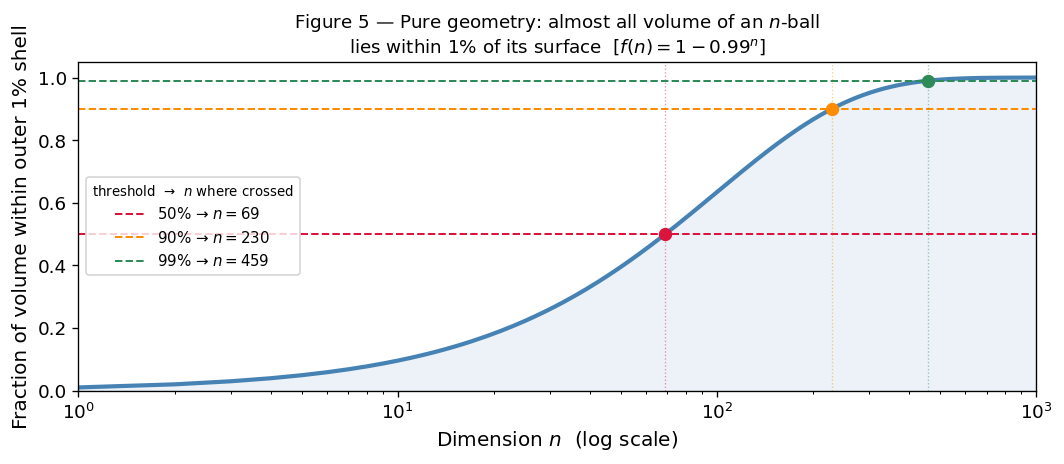

50% crossing:  n = 69
90% crossing:  n = 230
99% crossing:  n = 459


In [6]:
# ── Figure 5: fraction of n-ball volume within outer 1% shell ───────────────
# f(n) = 1 - 0.99^n  (exact for uniform distribution in an n-ball)
n_vals = np.arange(1, 1001)
f_vals = 1.0 - 0.99 ** n_vals

# crossing points (analytic)
n_50  = int(np.ceil(np.log(0.50) / np.log(0.99)))   # ~69
n_90  = int(np.ceil(np.log(0.10) / np.log(0.99)))   # ~229
n_99  = int(np.ceil(np.log(0.01) / np.log(0.99)))   # ~458

fig, ax = plt.subplots(figsize=(9, 4))
ax.semilogx(n_vals, f_vals, color="steelblue", lw=2.5)
ax.fill_between(n_vals, f_vals, 0, alpha=0.10, color="steelblue")

for level, n_cross, col, lbl in [
    (0.50, n_50,  "crimson",    "50%"),
    (0.90, n_90,  "darkorange", "90%"),
    (0.99, n_99,  "seagreen",   "99%"),
]:
    ax.axhline(level, color=col, lw=1.2, linestyle="--",
               label=f"{lbl} → $n = {n_cross}$")
    ax.axvline(n_cross, color=col, lw=0.8, linestyle=":", alpha=0.45)
    ax.plot(n_cross, level, "o", color=col, ms=7)

ax.set_xlabel("Dimension $n$  (log scale)", fontsize=12)
ax.set_ylabel("Fraction of volume within outer 1% shell", fontsize=12)
ax.set_title(
    "Figure 5 — Pure geometry: almost all volume of an $n$-ball\n"
    r"lies within 1% of its surface  [$f(n) = 1 - 0.99^n$]",
    fontsize=11,
)
ax.set_ylim(0, 1.05); ax.set_xlim(1, 1000)
ax.legend(fontsize=9, title="threshold  →  $n$ where crossed", title_fontsize=8)
plt.tight_layout()
plt.savefig("figures/fig5_volume_concentration.png", dpi=200)
plt.show()

print(f"50% crossing:  n = {n_50}")
print(f"90% crossing:  n = {n_90}")
print(f"99% crossing:  n = {n_99}")

## Figure 6 — The payoff: why prior sampling collapses in practice

In Notebook 1 the MC estimator is

$$\log p_\theta(x_i) \;\approx\; \log\!\left(\frac{1}{M}\sum_{m=1}^{M} p_\theta(x_i \mid z^{(m)})\right), \qquad z^{(m)} \sim \mathcal{N}(0, I_D)$$

For this to have low variance, a reasonable fraction of the $M$ prior samples must land in the
**posterior pocket** — the region of $z$-space that actually explains $x_i$.

We model the pocket as a ball of radius 0.5 around the "true" latent code for $x_i$, which
sits on the typical shell at

$$t_D = \sqrt{D}\, e_1 \qquad (e_1 = \text{first standard basis vector})$$

The **hit rate** — fraction of $M = 100{,}000$ prior samples landing inside the pocket —
measures how effective the MC estimator actually is.

The exact hit probability is $P(\|z - t_D\|^2 < 0.25)$ where $\|z - t_D\|^2 \sim \chi^2(D,\, \lambda=D)$
(non-central chi-squared with $D$ degrees of freedom and non-centrality $\lambda = D$).

D=  2 | simulated: 4.58e-02
D=  3 | simulated: 7.33e-03
D=  4 | simulated: 1.12e-03
D=  5 | simulated: 1.28e-04
D=  7 | simulated: 2.00e-06
D= 10 | simulated: 0.00e+00
D= 15 | simulated: 0.00e+00
D= 20 | simulated: 0.00e+00
D= 25 | simulated: 0.00e+00


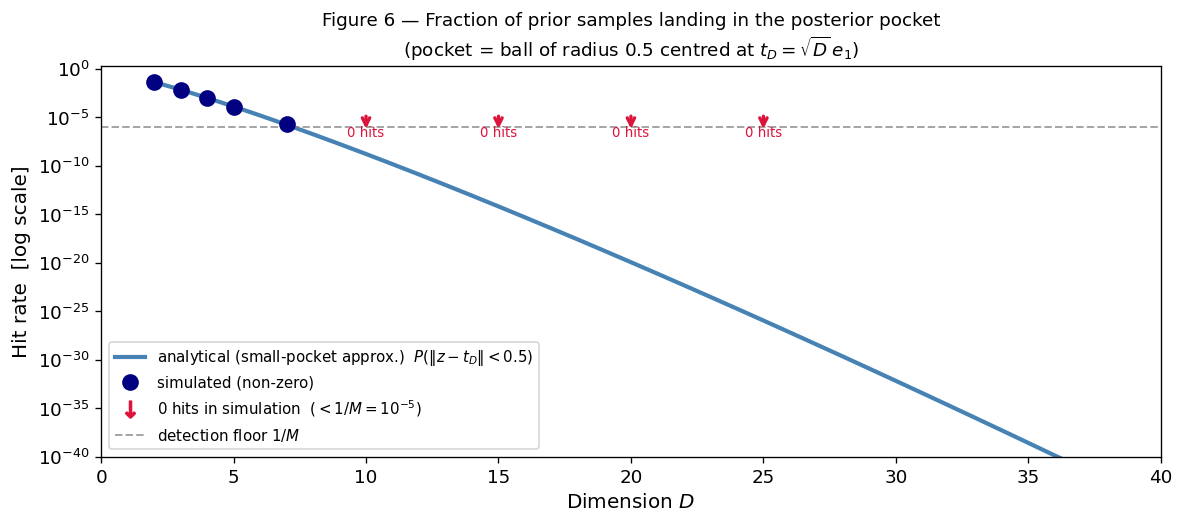

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import gammaln

np.random.seed(SEED)

M        = 1000000
POCKET_R = 0.5
D_SIM    = [2,3,4,5,7, 10,15, 20,25]

# ── simulation (empirical hit rate) ──────────────────────────────────────────
hit_rates = {}
for D in D_SIM:
    z   = np.random.randn(M, D)
    t_D = np.zeros(D); t_D[0] = np.sqrt(D)            # target on the typical shell
    hr  = float(np.mean(np.linalg.norm(z - t_D, axis=1) < POCKET_R))
    hit_rates[D] = hr
    print(f"D={D:3d} | simulated: {hr:.2e}")

# ── analytical curve in LOG space (never underflows) ─────────────────────────
# Small-pocket approximation: hit ≈ (Gaussian density at t_D) × (pocket volume)
#   = exp(-D/2) · 2^(-3D/2) / Γ(D/2 + 1)
D_dense   = np.arange(2, 85)
log10_hit = (-D_dense/2
             - (3*D_dense/2)*np.log(2)
             - gammaln(D_dense/2 + 1)) / np.log(10)
p_analytic = 10.0 ** log10_hit                        # fine for D ≤ 84 (~1e-108 min)

# ── plot ─────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10., 4.5))

ax.semilogy(D_dense, p_analytic, color="steelblue", lw=2.5,
            label=r"analytical (small-pocket approx.)  $P(\|z - t_D\| < 0.5)$")

_sim_label = False
for D, hr in hit_rates.items():
    if hr > 0:
        ax.semilogy(D, hr, "o", color="navy", ms=9, zorder=5,
                    label="simulated (non-zero)" if not _sim_label else "")
        _sim_label = True
    else:
        ax.annotate("", xy=(D, 3e-7), xytext=(D, 3e-5),
                    arrowprops=dict(arrowstyle="->", color="crimson", lw=2))
        ax.text(D, 1e-7, "0 hits", ha="center", fontsize=8, color="crimson")

ax.semilogy([], [], color="crimson", lw=0, marker=r"$\downarrow$", ms=10,
            label=r"0 hits in simulation  ($< 1/M = 10^{-5}$)")
ax.axhline(1/M, color="grey", lw=1.2, ls="--", alpha=0.7,
           label=r"detection floor $1/M$")

ax.annotate(r"keeps falling — $\approx 10^{-108}$ by $D=84$",
            xy=(46, 1e-34), fontsize=9, color="steelblue", ha="center")

ax.set_xlabel("Dimension $D$", fontsize=12)
ax.set_ylabel("Hit rate  [log scale]", fontsize=12)
ax.set_title("Figure 6 — Fraction of prior samples landing in the posterior pocket\n"
             r"(pocket = ball of radius 0.5 centred at $t_D = \sqrt{D}\,e_1$)",
             fontsize=11)
ax.set_xlim(0, 40)
ax.set_ylim(1e-40, 2)        # no clamp → line exits the bottom still descending
ax.legend(fontsize=9, loc="lower left")
plt.tight_layout()
plt.savefig("figures/fig6_hit_rate.png", dpi=200)
plt.show()

## Closing — The fix: learn a proposal, don't sample blind

The six figures tell a consistent story:

| Figure | Key finding |
|--------|-------------|
| 1–2 | Samples land on a shell at $r \approx \sqrt{D}$, far from the high-density mode |
| 3 | The shell narrows relative to its radius ($\Delta r / r \sim 1/\sqrt{D}$) as $D$ grows |
| 4 | The fraction of mass inside the unit ball collapses exponentially |
| 5 | Pure geometry: almost all volume of any high-$D$ ball is near its surface |
| 6 | Prior sampling hits the posterior pocket with probability that drops to zero |

**The bottom line:**

Prior mass lives on a vast shell. Any one $x_i$'s posterior pocket is a tiny patch on that
shell. A random prior sample almost never lands there, so the MC estimator

$$\log p_\theta(x_i) \approx \log\!\left(\frac{1}{M}\sum_m p_\theta(x_i \mid z^{(m)})\right)$$

is dominated by $M$ near-zero terms — high variance, slow learning.

**The fix:** learn an **encoder** $q_\phi(z \mid x)$ that proposes $z$-values aimed directly
at the posterior pocket instead of sampling blindly from the whole shell.
This gives a low-variance, directed estimate through **importance sampling**,
and the resulting bound on $\log p_\theta(x)$ is the **ELBO** — the topic of Notebook 3.